# NCR Ride-Hailing Data Analysis
### A Data Science & Machine Learning Study of Ride Bookings in the National Capital Region (Delhi NCR)

**Prepared by:** Data Analytics Team
**Dataset:** `ncr_ride_bookings.csv` — 150,000 ride bookings across 176 pickup/drop localities in Delhi NCR

---

**Objective:** Identify which **areas (towns/localities)**, **routes**, and **vehicle types** perform best in terms of completion rate, revenue, and customer satisfaction, and build a suite of machine learning models — regression, a linear perceptron, classification, clustering (K-Means & DBSCAN), and a neural network — to predict ride outcomes and segment ride behavior.

> **Note on scope:** The dataset records *pickup* and *drop locality* (e.g. "Palam Vihar", "Shastri Nagar") rather than individual street/road names. Throughout this notebook we treat each **Pickup → Drop pair as a "route" (proxy for a road/corridor)**, and each locality as a **"town/area"**. This is stated explicitly so results are interpreted correctly.

**Contents**
1. Data Loading & Cleaning
2. Exploratory Data Analysis
3. Town / Area Performance Analysis
4. Route ("Road") Analysis
5. Vehicle Type Performance
6. Cancellation Analysis
7. Correlation & Linear Regression
8. Linear Perceptron Classifier
9. Classification Models (Logistic Regression & Random Forest)
10. Clustering — K-Means Segmentation
11. Clustering — DBSCAN Density Analysis
12. Neural Network Model
13. Model Comparison Summary
14. Business Insights & Recommendations


In [1]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, silhouette_score)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
COLORS = ['#2E4374', '#4C7DBF', '#7FA8D9', '#F2A93B', '#E85D4C', '#5CA47A']

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

print('Libraries loaded successfully.')


Libraries loaded successfully.


## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv('ncr_ride_bookings.csv')
print(f'Raw shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Raw shape: 150,000 rows x 21 columns


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
# Clean ID columns (stored with extra quote characters, e.g. '"CNR5884300"')
df['Booking ID'] = df['Booking ID'].str.replace('"', '', regex=False)
df['Customer ID'] = df['Customer ID'].str.replace('"', '', regex=False)

# Parse date & time into a single datetime column, and derive time features
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.day_name()
df['Month'] = df['DateTime'].dt.month_name()
df['MonthNum'] = df['DateTime'].dt.month

# Route = Pickup -> Drop pair (proxy for a "road"/corridor)
df['Route'] = df['Pickup Location'] + ' -> ' + df['Drop Location']

# Binary completion flag used throughout the ML sections
df['IsCompleted'] = (df['Booking Status'] == 'Completed').astype(int)

print('Missing values per column:')
display(df.isnull().sum().to_frame('Missing').assign(Pct=lambda x: (x['Missing']/len(df)*100).round(1)))


Missing values per column:


,Missing,Pct
Date,0,0.0
Time,0,0.0
Booking ID,0,0.0
Booking Status,0,0.0
Customer ID,0,0.0
Vehicle Type,0,0.0
Pickup Location,0,0.0
Drop Location,0,0.0
Avg VTAT,10500,7.0
Avg CTAT,48000,32.0


**Interpretation of missing values:** Most nulls are *structural*, not data-quality issues. For example, `Booking Value`, `Ride Distance`, and `Driver/Customer Ratings` are only populated for **Completed** trips — a cancelled or "No Driver Found" booking never reaches the stage where distance, fare, or ratings are recorded. We keep this in mind and filter appropriately in each section below rather than imputing these fields blindly.

## 2. Exploratory Data Analysis

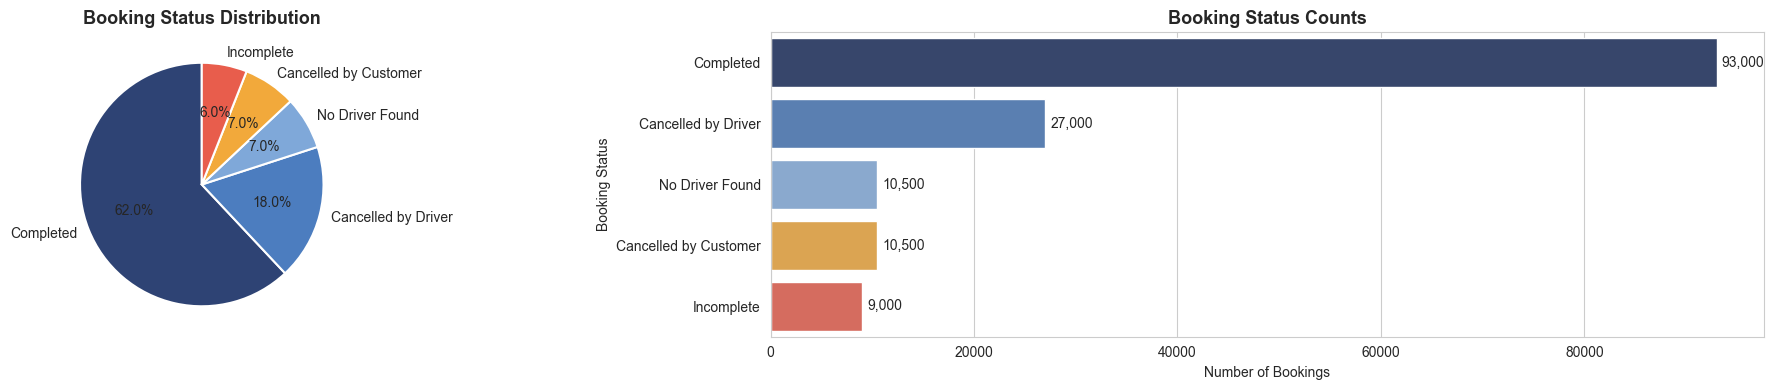

Overall completion rate: 62.0%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(21, 4))

status_counts = df['Booking Status'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=COLORS,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, startangle=90)
axes[0].set_title('Booking Status Distribution')

sns.barplot(x=status_counts.values, y=status_counts.index, ax=axes[1], palette=COLORS)
axes[1].set_title('Booking Status Counts')
axes[1].set_xlabel('Number of Bookings')
for i, v in enumerate(status_counts.values):
    axes[1].text(v + 500, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

completion_rate = df['IsCompleted'].mean() * 100
print(f'Overall completion rate: {completion_rate:.1f}%')


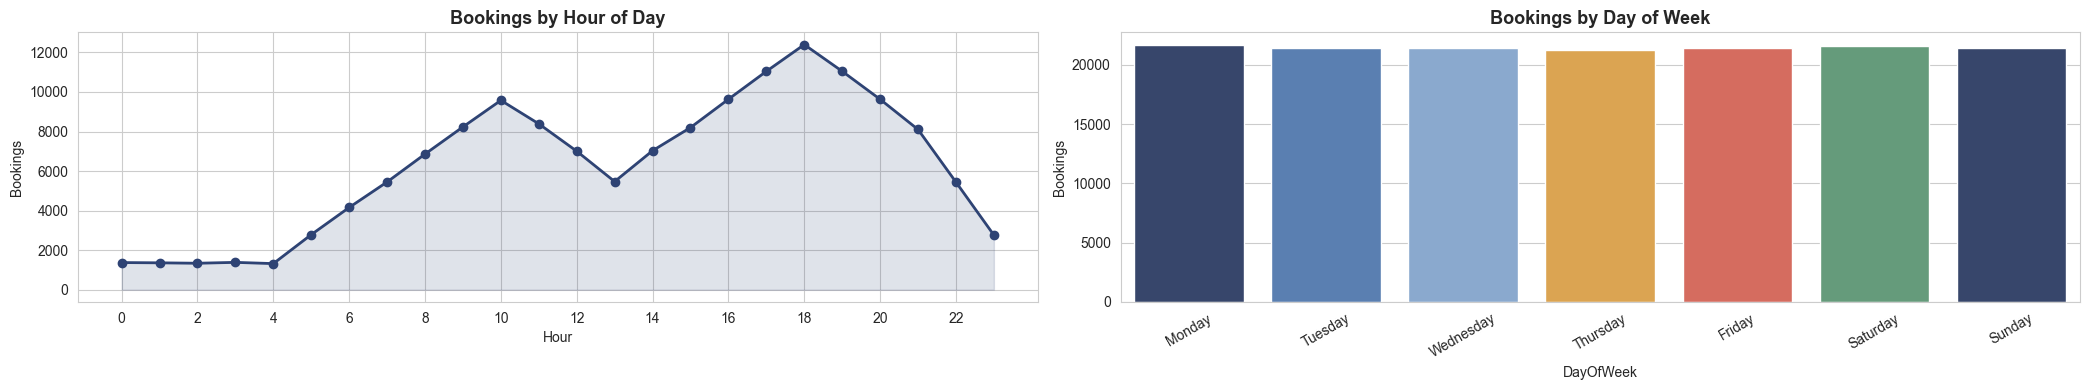

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(21, 4))

hourly = df.groupby('Hour').size()
axes[0].plot(hourly.index, hourly.values, marker='o', color=COLORS[0], linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.15, color=COLORS[0])
axes[0].set_title('Bookings by Hour of Day')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Bookings')
axes[0].set_xticks(range(0, 24, 2))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('DayOfWeek').size().reindex(dow_order)
sns.barplot(x=dow.index, y=dow.values, ax=axes[1], palette=COLORS*2)
axes[1].set_title('Bookings by Day of Week')
axes[1].set_ylabel('Bookings')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


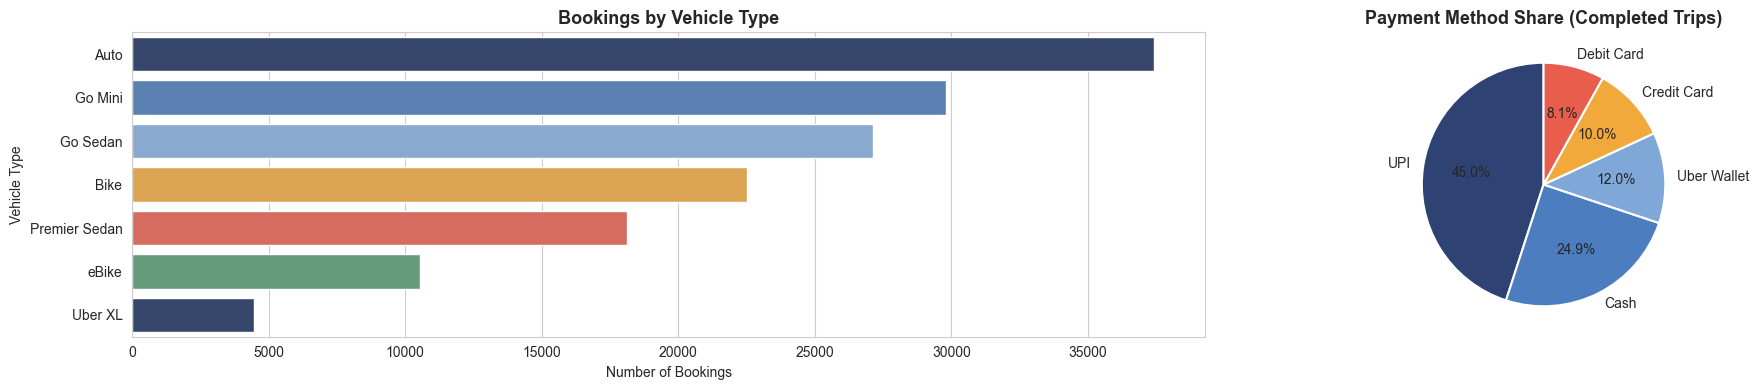

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(21, 4))

veh_counts = df['Vehicle Type'].value_counts()
sns.barplot(x=veh_counts.values, y=veh_counts.index, ax=axes[0], palette=COLORS*2)
axes[0].set_title('Bookings by Vehicle Type')
axes[0].set_xlabel('Number of Bookings')

pay_counts = df['Payment Method'].dropna().value_counts()
axes[1].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', colors=COLORS,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, startangle=90)
axes[1].set_title('Payment Method Share (Completed Trips)')

plt.tight_layout()
plt.show()


## 3. Town / Area Performance Analysis
We evaluate every locality that appears as a **pickup point** on three dimensions: demand volume, completion rate, and average customer rating. This tells us which towns are the most reliable / best-served areas in the network.

In [7]:
area_stats = df.groupby('Pickup Location').agg(
    Total_Bookings=('Booking ID', 'count'),
    Completion_Rate=('IsCompleted', 'mean'),
    Avg_Booking_Value=('Booking Value', 'mean'),
    Avg_Customer_Rating=('Customer Rating', 'mean'),
    Avg_Driver_Rating=('Driver Ratings', 'mean')
).round(2)
area_stats['Completion_Rate'] = (area_stats['Completion_Rate'] * 100).round(1)

# Only consider areas with meaningful volume for a fair ranking
area_stats_min = area_stats[area_stats['Total_Bookings'] >= 200]

print('Top 10 BEST performing pickup areas (by completion rate, min. 200 bookings):')
best_areas = area_stats_min.sort_values('Completion_Rate', ascending=False).head(10)
display(best_areas)

print('\\nTop 10 pickup areas with the LOWEST completion rate (need attention):')
worst_areas = area_stats_min.sort_values('Completion_Rate', ascending=True).head(10)
display(worst_areas)


Top 10 BEST performing pickup areas (by completion rate, min. 200 bookings):


,Total_Bookings,Completion_Rate,Avg_Booking_Value,Avg_Customer_Rating,Avg_Driver_Rating
Pickup Location,,,,,
Welcome,836,66.0,517.62,4.42,4.24
Subhash Chowk,887,66.0,518.72,4.38,4.24
RK Puram,850,65.0,502.61,4.40,4.23
IMT Manesar,840,65.0,534.96,4.41,4.23
Sushant Lok,850,65.0,493.69,4.41,4.22
Yamuna Bank,824,65.0,503.63,4.35,4.23
Anand Vihar,859,64.0,490.94,4.41,4.22
Ashok Park Main,884,64.0,515.20,4.42,4.24
IGI Airport,879,64.0,492.27,4.40,4.22


\nTop 10 pickup areas with the LOWEST completion rate (need attention):


,Total_Bookings,Completion_Rate,Avg_Booking_Value,Avg_Customer_Rating,Avg_Driver_Rating
Pickup Location,,,,,
Vinobapuri,823,55.0,503.40,4.42,4.23
Akshardham,839,56.0,485.97,4.42,4.25
Chhatarpur,829,58.0,496.34,4.37,4.22
Badshahpur,868,58.0,519.28,4.40,4.19
Pragati Maidan,920,58.0,503.84,4.40,4.19
IFFCO Chowk,830,59.0,515.29,4.38,4.26
Keshav Puram,865,59.0,538.66,4.39,4.24
Indirapuram,854,59.0,515.96,4.38,4.21
Lal Quila,827,59.0,495.67,4.40,4.26


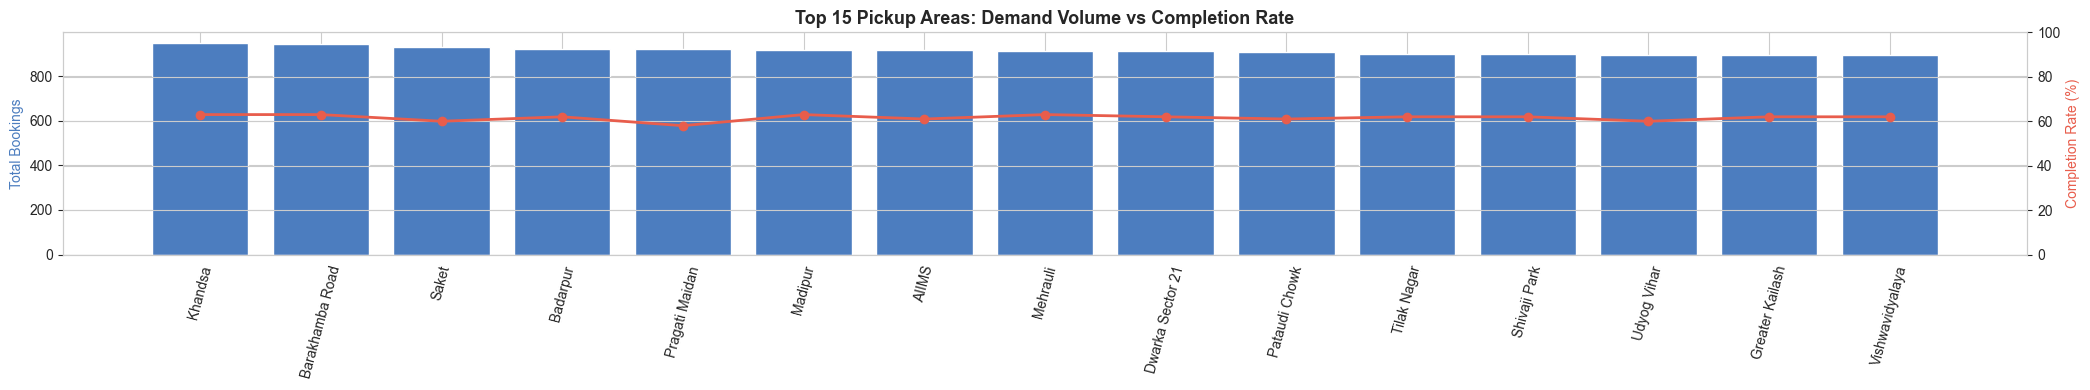

In [8]:
top15_volume = area_stats.sort_values('Total_Bookings', ascending=False).head(15)

fig, ax1 = plt.subplots(figsize=(21, 4))
ax1.bar(top15_volume.index, top15_volume['Total_Bookings'], color=COLORS[1], label='Total Bookings')
ax1.set_ylabel('Total Bookings', color=COLORS[1])
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(top15_volume.index, top15_volume['Completion_Rate'], color=COLORS[4], marker='o', linewidth=2, label='Completion Rate (%)')
ax2.set_ylabel('Completion Rate (%)', color=COLORS[4])
ax2.set_ylim(0, 100)

plt.title('Top 15 Pickup Areas: Demand Volume vs Completion Rate')
fig.tight_layout()
plt.show()


## 4. Route ("Road" / Corridor) Analysis
Since the dataset does not expose individual road/street names, we define a **route** as a Pickup → Drop locality pair — the closest available proxy for a road/corridor in this data.

In [9]:
route_stats = df.groupby('Route').agg(
    Total_Bookings=('Booking ID', 'count'),
    Completion_Rate=('IsCompleted', 'mean'),
    Avg_Distance_km=('Ride Distance', 'mean'),
    Avg_Booking_Value=('Booking Value', 'mean')
).round(2)
route_stats['Completion_Rate'] = (route_stats['Completion_Rate'] * 100).round(1)
route_stats['Revenue_per_km'] = (route_stats['Avg_Booking_Value'] / route_stats['Avg_Distance_km']).round(2)

print('Top 10 busiest routes:')
display(route_stats.sort_values('Total_Bookings', ascending=False).head(10))

route_stats_min = route_stats[route_stats['Total_Bookings'] >= 8]
print('\\nTop 10 most VALUABLE routes (highest revenue per km, min. 8 bookings):')
display(route_stats_min.sort_values('Revenue_per_km', ascending=False).head(10))


Top 10 busiest routes:


,Total_Bookings,Completion_Rate,Avg_Distance_km,Avg_Booking_Value,Revenue_per_km
Route,,,,,
DLF City Court -> Bhiwadi,17,76.0,29.64,429.21,14.48
Akshardham -> RK Puram,16,44.0,19.91,558.78,28.07
Janakpuri -> Faridabad Sector 15,16,56.0,21.22,506.80,23.88
Vatika Chowk -> Rithala,15,60.0,17.10,364.11,21.29
Rithala -> Udyog Vihar Phase 4,15,73.0,18.86,575.00,30.49
Jor Bagh -> Rohini East,15,47.0,25.90,214.12,8.27
Ghaziabad -> Badshahpur,15,40.0,24.36,491.29,20.17
Kashmere Gate ISBT -> Tilak Nagar,14,50.0,22.07,287.70,13.04
Chirag Delhi -> Noida Film City,14,50.0,23.61,423.75,17.95


\nTop 10 most VALUABLE routes (highest revenue per km, min. 8 bookings):


,Total_Bookings,Completion_Rate,Avg_Distance_km,Avg_Booking_Value,Revenue_per_km
Route,,,,,
Jor Bagh -> Qutub Minar,8,12.0,3.29,702.25,213.45
Welcome -> Hauz Rani,9,44.0,10.90,1207.80,110.81
Central Secretariat -> Ardee City,8,25.0,5.11,482.00,94.32
AIIMS -> Palam Vihar,8,62.0,14.62,1301.80,89.04
Welcome -> Nawada,8,38.0,4.58,396.25,86.52
Rohini West -> Peeragarhi,8,25.0,6.71,565.00,84.20
Shastri Park -> Greater Kailash,8,38.0,9.84,825.33,83.88
Gurgaon Railway Station -> Kaushambi,8,62.0,15.95,1327.20,83.21
IFFCO Chowk -> Noida Film City,8,50.0,8.08,640.40,79.26


## 5. Vehicle Type Performance

,Total_Bookings,Completion_Rate,Avg_Booking_Value,Avg_Distance_km,Avg_Driver_Rating,Avg_Customer_Rating,Revenue_per_km
Vehicle Type,,,,,,,
Uber XL,4449,63.0,501.82,24.40,4.24,4.40,20.57
Bike,22517,62.0,510.20,24.65,4.23,4.40,20.70
Auto,37419,62.0,506.73,24.62,4.23,4.40,20.58
Go Mini,29806,62.0,507.68,24.61,4.23,4.40,20.63
Premier Sedan,18111,62.0,509.57,24.60,4.23,4.40,20.71
eBike,10557,62.0,503.90,24.99,4.23,4.40,20.16
Go Sedan,27141,61.0,511.50,24.61,4.23,4.41,20.78


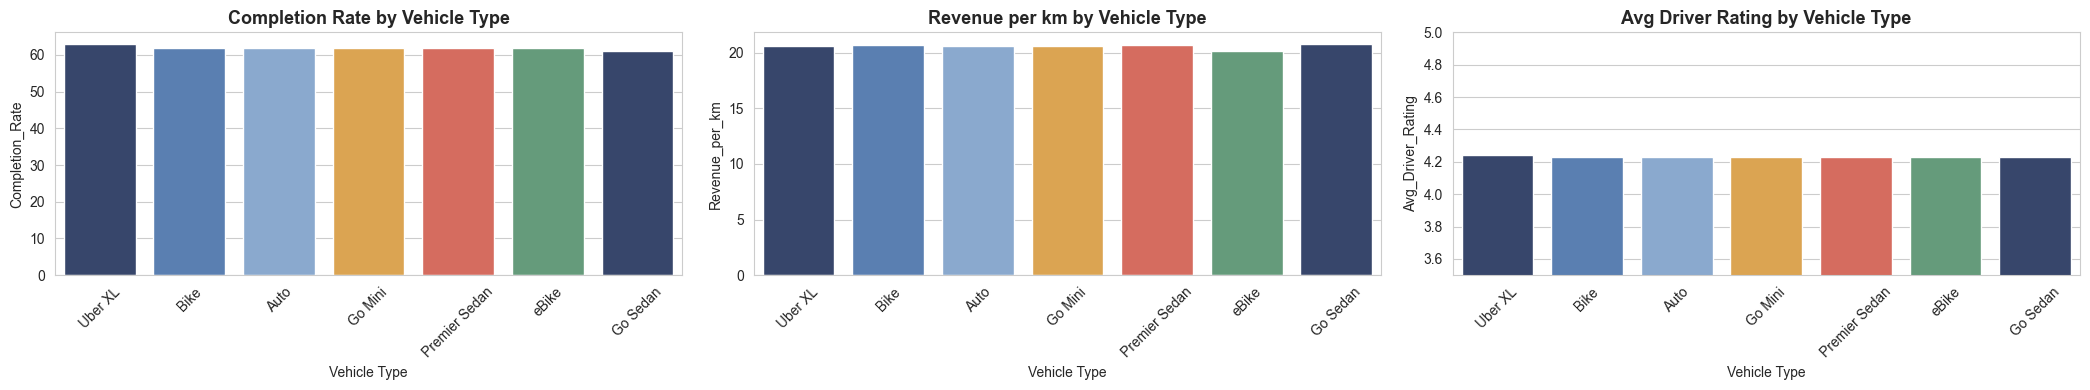

Best all-round vehicle type by completion rate: Uber XL
Best vehicle type by revenue per km: Go Sedan


In [10]:
vt_stats = df.groupby('Vehicle Type').agg(
    Total_Bookings=('Booking ID', 'count'),
    Completion_Rate=('IsCompleted', 'mean'),
    Avg_Booking_Value=('Booking Value', 'mean'),
    Avg_Distance_km=('Ride Distance', 'mean'),
    Avg_Driver_Rating=('Driver Ratings', 'mean'),
    Avg_Customer_Rating=('Customer Rating', 'mean')
).round(2)
vt_stats['Completion_Rate'] = (vt_stats['Completion_Rate'] * 100).round(1)
vt_stats['Revenue_per_km'] = (vt_stats['Avg_Booking_Value'] / vt_stats['Avg_Distance_km']).round(2)
vt_stats = vt_stats.sort_values('Completion_Rate', ascending=False)
display(vt_stats)

fig, axes = plt.subplots(1, 3, figsize=(21, 4))
sns.barplot(x=vt_stats.index, y=vt_stats['Completion_Rate'], ax=axes[0], palette=COLORS*2)
axes[0].set_title('Completion Rate by Vehicle Type'); axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=vt_stats.index, y=vt_stats['Revenue_per_km'], ax=axes[1], palette=COLORS*2)
axes[1].set_title('Revenue per km by Vehicle Type'); axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x=vt_stats.index, y=vt_stats['Avg_Driver_Rating'], ax=axes[2], palette=COLORS*2)
axes[2].set_title('Avg Driver Rating by Vehicle Type'); axes[2].set_ylim(3.5, 5)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Best all-round vehicle type by completion rate: {vt_stats['Completion_Rate'].idxmax()}")
print(f"Best vehicle type by revenue per km: {vt_stats['Revenue_per_km'].idxmax()}")


## 6. Cancellation Analysis

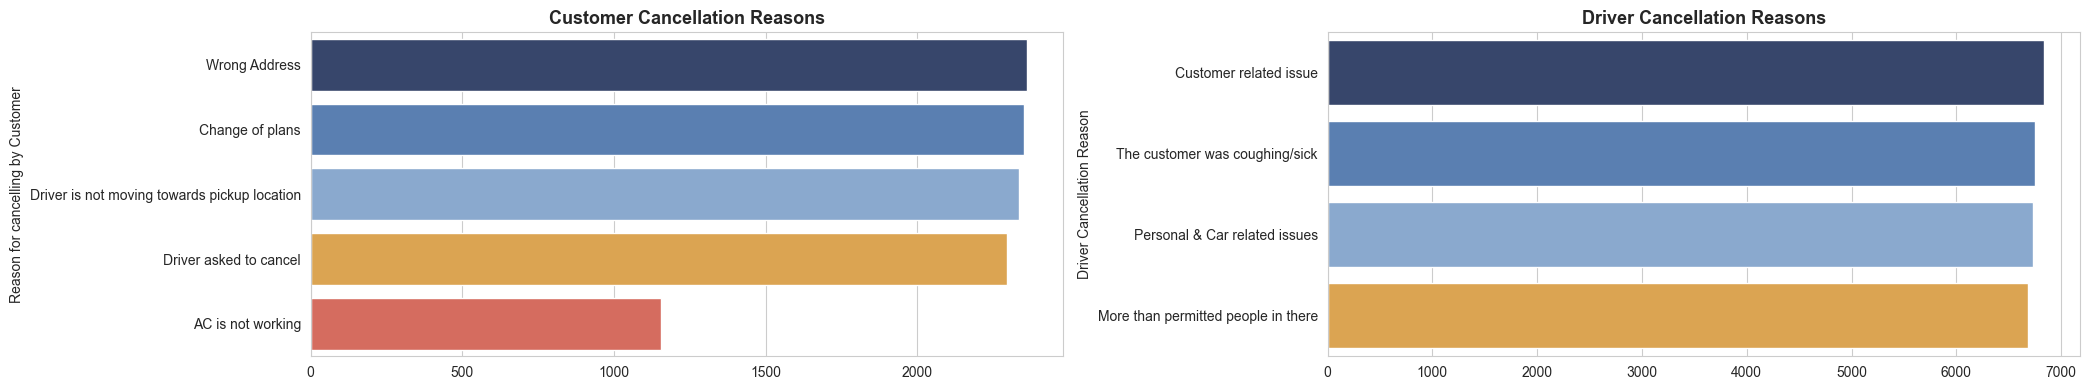

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(21, 4))

cust_reasons = df['Reason for cancelling by Customer'].value_counts()
sns.barplot(x=cust_reasons.values, y=cust_reasons.index, ax=axes[0], palette=COLORS*2)
axes[0].set_title('Customer Cancellation Reasons')

drv_reasons = df['Driver Cancellation Reason'].value_counts()
sns.barplot(x=drv_reasons.values, y=drv_reasons.index, ax=axes[1], palette=COLORS*2)
axes[1].set_title('Driver Cancellation Reasons')

plt.tight_layout()
plt.show()


## 7. Correlation & Linear Regression
**Goal:** Predict `Booking Value` (fare) from ride characteristics using **Linear Regression**.

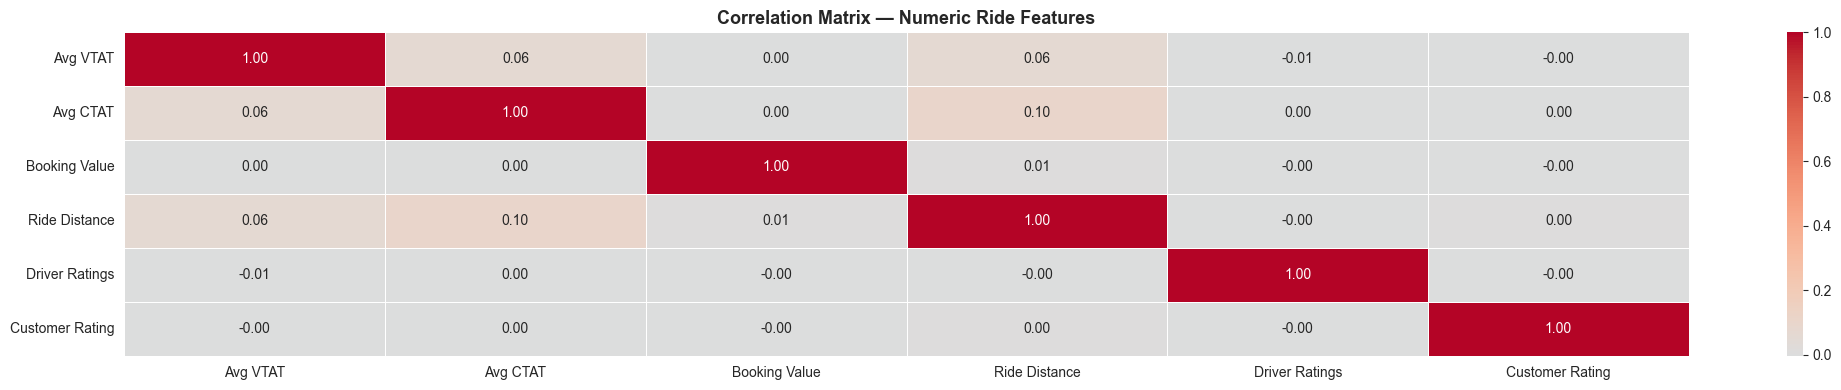

In [12]:
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
corr = df[num_cols].corr()

plt.figure(figsize=(21, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Numeric Ride Features')
plt.tight_layout()
plt.show()


Linear Regression — Predicting Booking Value
  R^2 score : -0.000
  RMSE      : 399.41
  MAE       : 287.48
\nCoefficients:
  Ride Distance      0.101
  Avg VTAT           0.294
  Avg CTAT          -0.017
  Vehicle_Enc        0.830
  Intercept        502.369


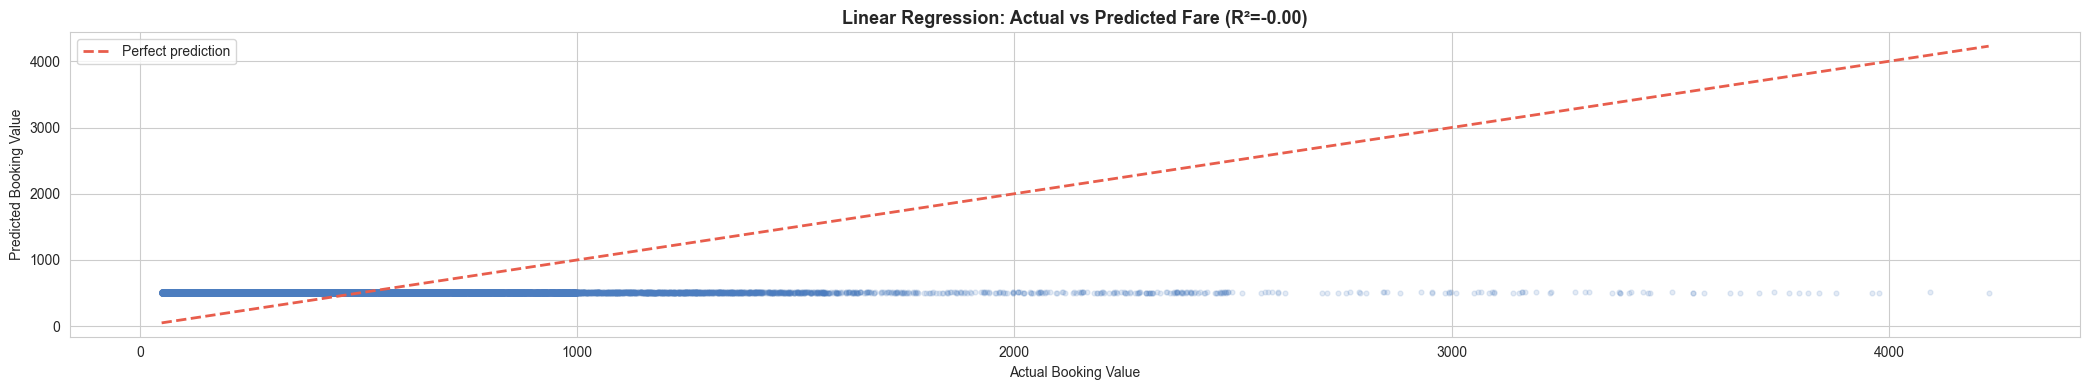

In [13]:
# Build regression dataset from completed rides only (these are the only rows with a fare)
reg_df = df[df['Booking Status'] == 'Completed'].copy()
reg_df = reg_df.dropna(subset=['Booking Value', 'Ride Distance', 'Avg VTAT', 'Avg CTAT'])

le_vehicle = LabelEncoder()
reg_df['Vehicle_Enc'] = le_vehicle.fit_transform(reg_df['Vehicle Type'])

X = reg_df[['Ride Distance', 'Avg VTAT', 'Avg CTAT', 'Vehicle_Enc']]
y = reg_df['Booking Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('Linear Regression — Predicting Booking Value')
print(f'  R^2 score : {r2:.3f}')
print(f'  RMSE      : {rmse:.2f}')
print(f'  MAE       : {mae:.2f}')
print('\\nCoefficients:')
for name, coef in zip(X.columns, lin_reg.coef_):
    print(f'  {name:15s} {coef:8.3f}')
print(f'  Intercept       {lin_reg.intercept_:8.3f}')

plt.figure(figsize=(21, 4))
plt.scatter(y_test, y_pred, alpha=0.15, color=COLORS[1], s=12)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color=COLORS[4], linewidth=2, linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Booking Value'); plt.ylabel('Predicted Booking Value')
plt.title(f'Linear Regression: Actual vs Predicted Fare (R\u00b2={r2:.2f})')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Linear Perceptron Classifier
As a lightweight linear baseline before the more expressive classifiers below, we fit a **Perceptron** (a single-layer linear neural unit) to separate **Completed** vs **Not Completed** rides.

Linear Perceptron — Completed vs Not Completed
  Accuracy : 0.581
  Precision: 0.662
  Recall   : 0.759
  F1-score : 0.707


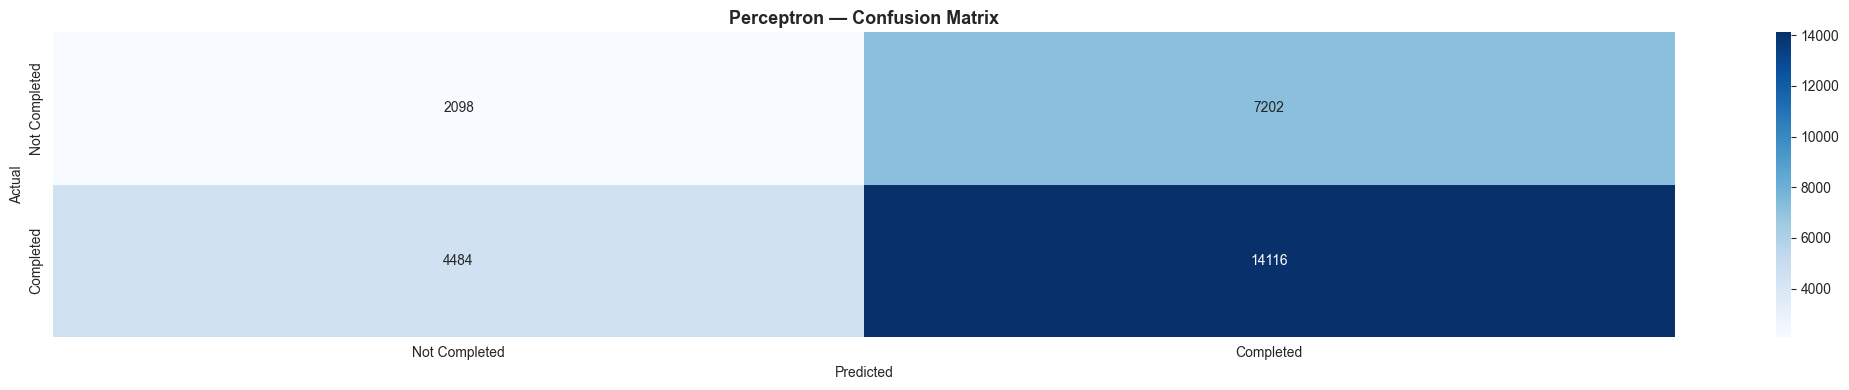

In [14]:
clf_df = df.dropna(subset=['Avg VTAT']).copy()  # rows that at least reached driver assignment
clf_df['Vehicle_Enc'] = LabelEncoder().fit_transform(clf_df['Vehicle Type'])

Xp = clf_df[['Avg VTAT', 'Vehicle_Enc']].fillna(0)
yp = clf_df['IsCompleted']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(Xp, yp, test_size=0.2, random_state=42, stratify=yp)

scaler_p = StandardScaler()
Xp_train_s = scaler_p.fit_transform(Xp_train)
Xp_test_s = scaler_p.transform(Xp_test)

perceptron = Perceptron(max_iter=1000, random_state=42)
perceptron.fit(Xp_train_s, yp_train)
yp_pred = perceptron.predict(Xp_test_s)

print('Linear Perceptron — Completed vs Not Completed')
print(f'  Accuracy : {accuracy_score(yp_test, yp_pred):.3f}')
print(f'  Precision: {precision_score(yp_test, yp_pred):.3f}')
print(f'  Recall   : {recall_score(yp_test, yp_pred):.3f}')
print(f'  F1-score : {f1_score(yp_test, yp_pred):.3f}')

cm = confusion_matrix(yp_test, yp_pred)
plt.figure(figsize=(21, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Completed','Completed'], yticklabels=['Not Completed','Completed'])
plt.title('Perceptron — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 9. Classification Models — Logistic Regression & Random Forest
**Goal:** Predict whether a booking will be **Completed** using richer, pre-trip information available at booking time (vehicle type, pickup hour, day of week, payment method preference is *not* known pre-trip so it's excluded to avoid leakage).

In [15]:
features_cat = ['Vehicle Type', 'Hour', 'DayOfWeek']
model_df = df.dropna(subset=['Hour']).copy()

le_dict = {}
for c in ['Vehicle Type', 'DayOfWeek']:
    le = LabelEncoder()
    model_df[c + '_enc'] = le.fit_transform(model_df[c])
    le_dict[c] = le

feature_cols = ['Vehicle Type_enc', 'Hour', 'DayOfWeek_enc']
X_cls = model_df[feature_cols]
y_cls = model_df['IsCompleted']

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results = {}


In [16]:
# --- Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)
y_pred_lr = log_reg.predict(X_test_s)

results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr)
}
print(classification_report(y_test, y_pred_lr, target_names=['Not Completed','Completed']))


               precision    recall  f1-score   support

Not Completed       0.00      0.00      0.00     11400
    Completed       0.62      1.00      0.77     18600

     accuracy                           0.62     30000
    macro avg       0.31      0.50      0.38     30000
 weighted avg       0.38      0.62      0.47     30000



               precision    recall  f1-score   support

Not Completed       0.50      0.00      0.00     11400
    Completed       0.62      1.00      0.77     18600

     accuracy                           0.62     30000
    macro avg       0.56      0.50      0.38     30000
 weighted avg       0.57      0.62      0.47     30000



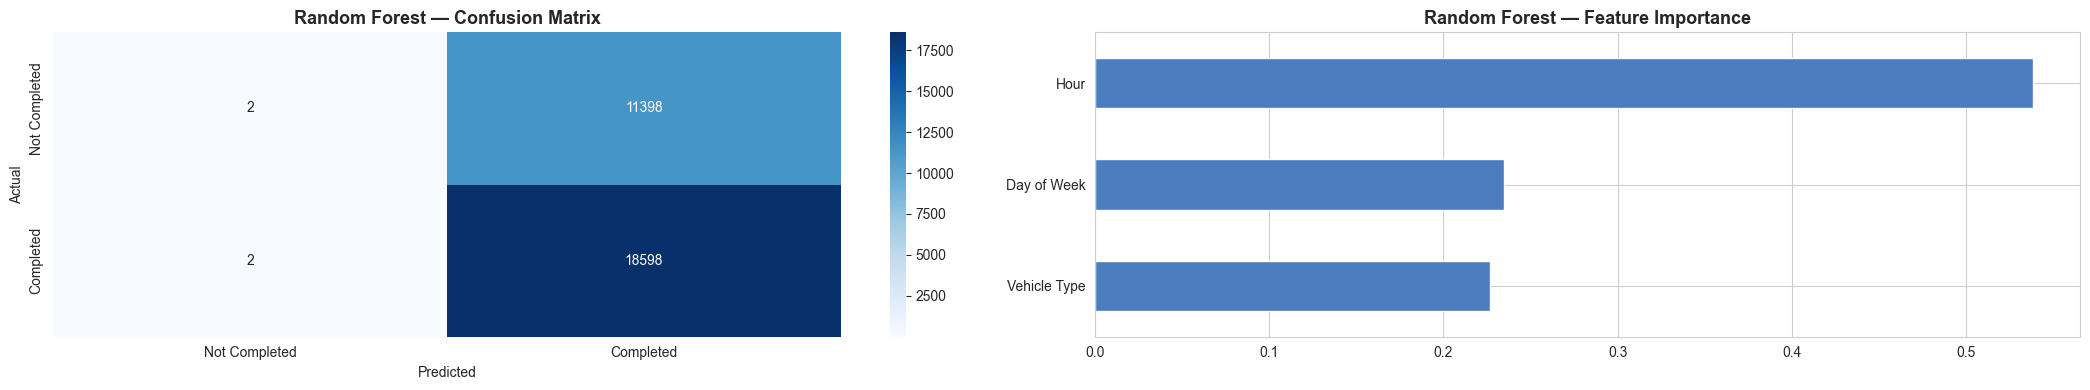

In [17]:
# --- Random Forest ---
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf)
}
print(classification_report(y_test, y_pred_rf, target_names=['Not Completed','Completed']))

fig, axes = plt.subplots(1, 2, figsize=(21, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Completed','Completed'], yticklabels=['Not Completed','Completed'])
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

importances = pd.Series(rf_clf.feature_importances_, index=['Vehicle Type', 'Hour', 'Day of Week'])
importances.sort_values().plot(kind='barh', ax=axes[1], color=COLORS[1])
axes[1].set_title('Random Forest — Feature Importance')

plt.tight_layout()
plt.show()


## 10. Clustering — K-Means Ride Segmentation
**Goal:** Segment completed rides into natural groups based on distance, fare, and pickup/turnaround times, to uncover ride "personas" (e.g. short cheap hops vs long premium trips).

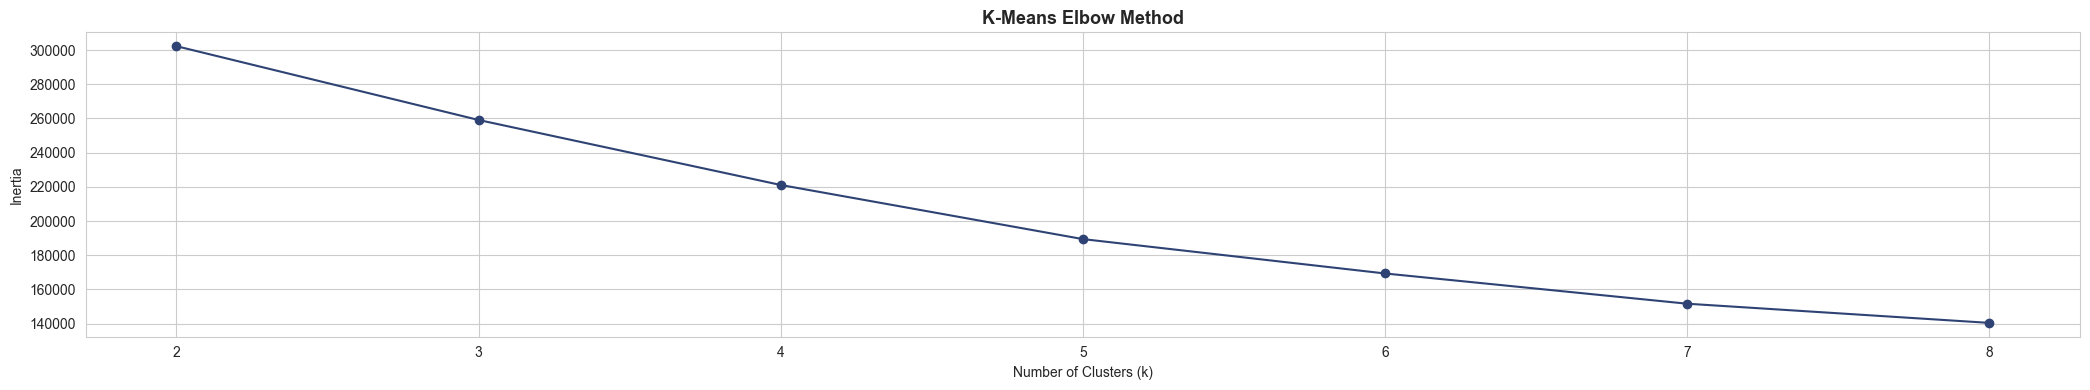

In [18]:
cluster_df = df[df['Booking Status'] == 'Completed'].dropna(
    subset=['Ride Distance', 'Booking Value', 'Avg VTAT', 'Avg CTAT']).copy()

cluster_features = ['Ride Distance', 'Booking Value', 'Avg VTAT', 'Avg CTAT']
Xc = cluster_df[cluster_features]

scaler_c = StandardScaler()
Xc_scaled = scaler_c.fit_transform(Xc)

# Elbow method to choose k
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xc_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(21, 4))
plt.plot(list(k_range), inertias, marker='o', color=COLORS[0])
plt.xlabel('Number of Clusters (k)'); plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.tight_layout()
plt.show()


Silhouette score (k=4): 0.196


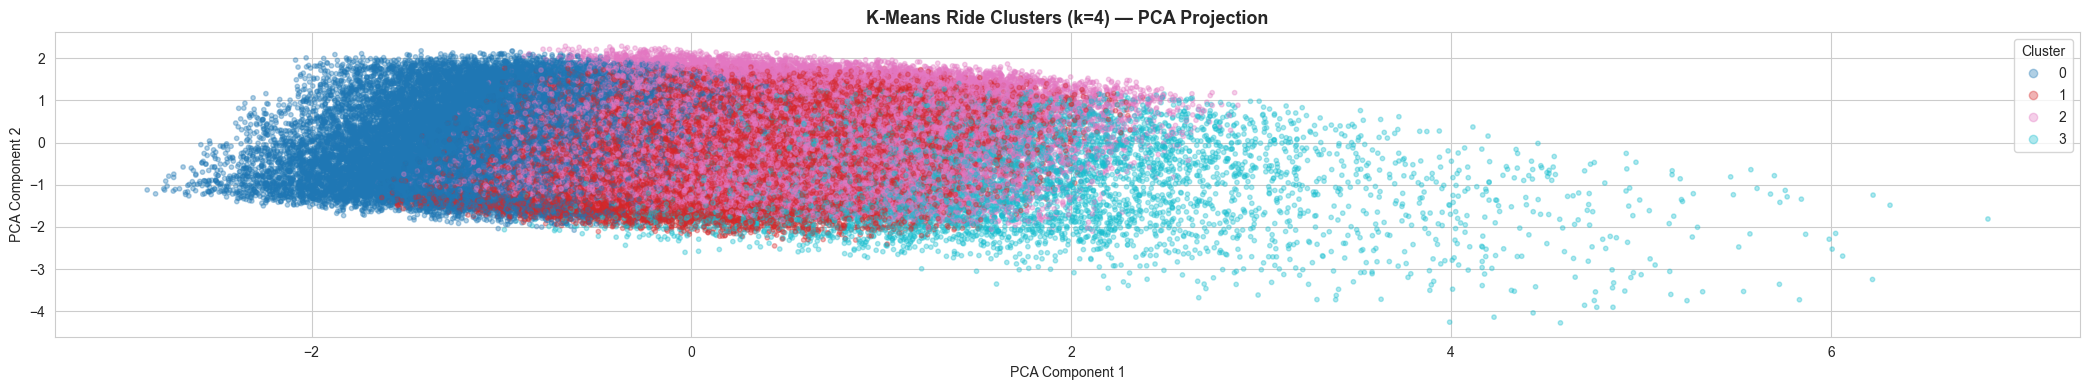

\nCluster profiles (mean values):


,Ride Distance,Booking Value,Avg VTAT,Avg CTAT,Count
Cluster,,,,,
0,13.16,422.70,5.96,30.14,26223
1,39.16,419.66,6.24,29.96,26774
2,25.37,419.88,12.49,30.06,31687
3,26.53,1399.16,8.71,29.84,8316


In [19]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(Xc_scaled)

sil = silhouette_score(Xc_scaled, cluster_df['Cluster'], sample_size=10000, random_state=42)
print(f'Silhouette score (k={K_FINAL}): {sil:.3f}')

# 2D visualization via PCA
pca = PCA(n_components=2, random_state=42)
Xc_pca = pca.fit_transform(Xc_scaled)

plt.figure(figsize=(21, 4))
scatter = plt.scatter(Xc_pca[:, 0], Xc_pca[:, 1], c=cluster_df['Cluster'], cmap='tab10', alpha=0.35, s=10)
plt.xlabel('PCA Component 1'); plt.ylabel('PCA Component 2')
plt.title(f'K-Means Ride Clusters (k={K_FINAL}) — PCA Projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()

print('\\nCluster profiles (mean values):')
display(cluster_df.groupby('Cluster')[cluster_features].mean().round(2).assign(
    Count=cluster_df.groupby('Cluster').size()))


## 11. Clustering — DBSCAN Density Analysis
DBSCAN complements K-Means by finding **dense regions of "typical" rides** and flagging **outlier/anomalous bookings** (e.g. unusually long-distance or high-fare trips) that do not belong to any cluster (`label = -1`).

DBSCAN found 1 dense clusters and flagged 470 rides (5.9%) as outliers.


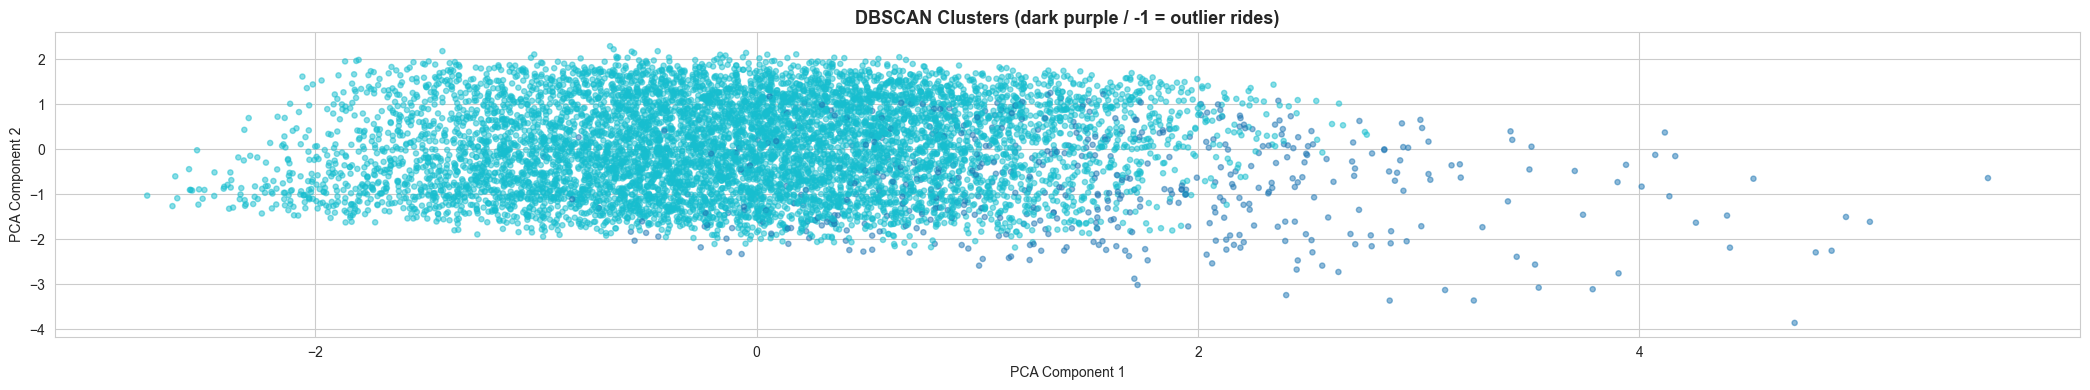

\nSample of flagged outlier rides:


,Ride Distance,Booking Value,Avg VTAT,Avg CTAT
90109,10.06,1563.0,11.1,40.8
16940,14.58,1276.0,2.4,44.1
107448,32.97,1213.0,14.4,40.2
87717,44.48,1131.0,11.5,28.8
126404,43.59,1483.0,7.0,18.2
79796,12.32,1312.0,2.3,18.8
111932,18.41,1457.0,13.9,28.6
9908,41.98,1296.0,7.5,35.8


In [20]:
# Use a sample for DBSCAN (density computations are expensive at 100k+ rows)
sample_df = cluster_df.sample(n=8000, random_state=42)
Xd = scaler_c.transform(sample_df[cluster_features])

dbscan = DBSCAN(eps=0.6, min_samples=15)
sample_df = sample_df.copy()
sample_df['DBSCAN_Cluster'] = dbscan.fit_predict(Xd)

n_clusters = len(set(sample_df['DBSCAN_Cluster'])) - (1 if -1 in sample_df['DBSCAN_Cluster'].values else 0)
n_noise = (sample_df['DBSCAN_Cluster'] == -1).sum()
print(f'DBSCAN found {n_clusters} dense clusters and flagged {n_noise} rides ({n_noise/len(sample_df)*100:.1f}%) as outliers.')

Xd_pca = pca.transform(Xd)
plt.figure(figsize=(21, 4))
plt.scatter(Xd_pca[:, 0], Xd_pca[:, 1], c=sample_df['DBSCAN_Cluster'], cmap='tab10', alpha=0.5, s=14)
plt.xlabel('PCA Component 1'); plt.ylabel('PCA Component 2')
plt.title('DBSCAN Clusters (dark purple / -1 = outlier rides)')
plt.tight_layout()
plt.show()

print('\\nSample of flagged outlier rides:')
display(sample_df[sample_df['DBSCAN_Cluster'] == -1][cluster_features].head(8))


## 12. Neural Network Model
**Goal:** Fit a small **Multi-Layer Perceptron (MLP) neural network** for the same completion-prediction task as Section 9, to see whether a non-linear model improves on Logistic Regression / Random Forest.

               precision    recall  f1-score   support

Not Completed       0.00      0.00      0.00     11400
    Completed       0.62      1.00      0.77     18600

     accuracy                           0.62     30000
    macro avg       0.31      0.50      0.38     30000
 weighted avg       0.38      0.62      0.47     30000



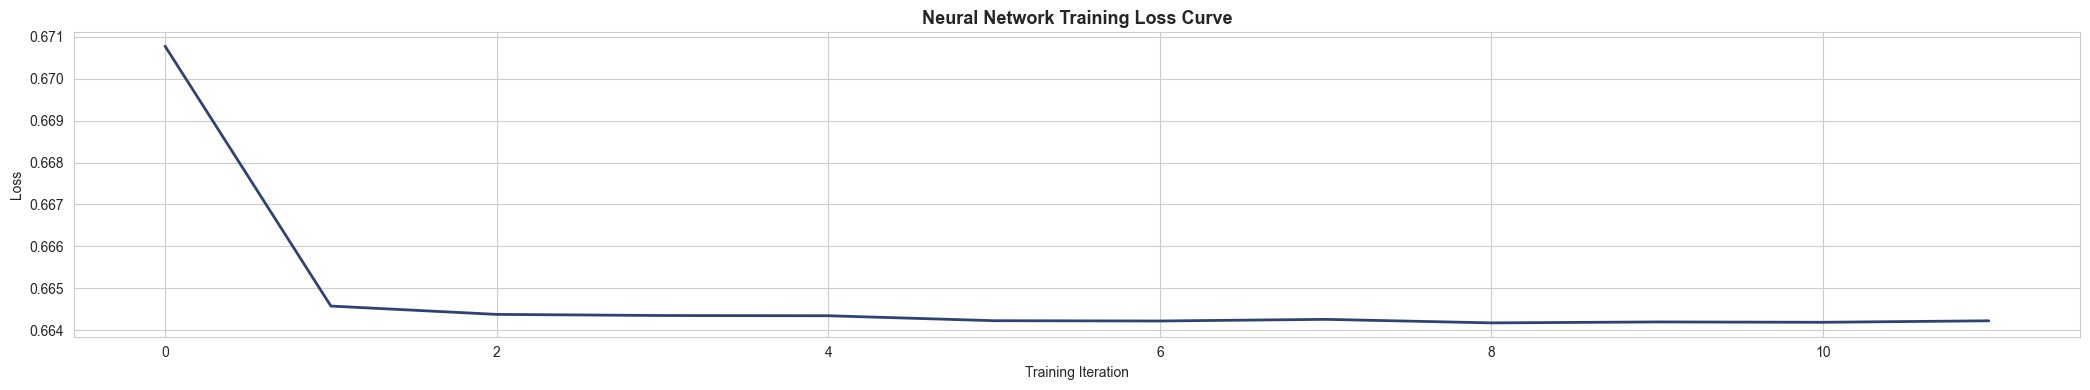

In [21]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', max_iter=300,
                     random_state=42, early_stopping=True)
mlp.fit(X_train_s, y_train)
y_pred_mlp = mlp.predict(X_test_s)

results['Neural Network (MLP)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall': recall_score(y_test, y_pred_mlp),
    'F1': f1_score(y_test, y_pred_mlp)
}
print(classification_report(y_test, y_pred_mlp, target_names=['Not Completed','Completed']))

plt.figure(figsize=(21, 4))
plt.plot(mlp.loss_curve_, color=COLORS[0], linewidth=2)
plt.xlabel('Training Iteration'); plt.ylabel('Loss')
plt.title('Neural Network Training Loss Curve')
plt.tight_layout()
plt.show()


## 13. Model Comparison Summary

,Accuracy,Precision,Recall,F1
Logistic Regression,0.620,0.620,1.000,0.765
Random Forest,0.620,0.620,1.000,0.765
Neural Network (MLP),0.620,0.620,1.000,0.765
Perceptron (linear baseline),0.581,0.662,0.759,0.707


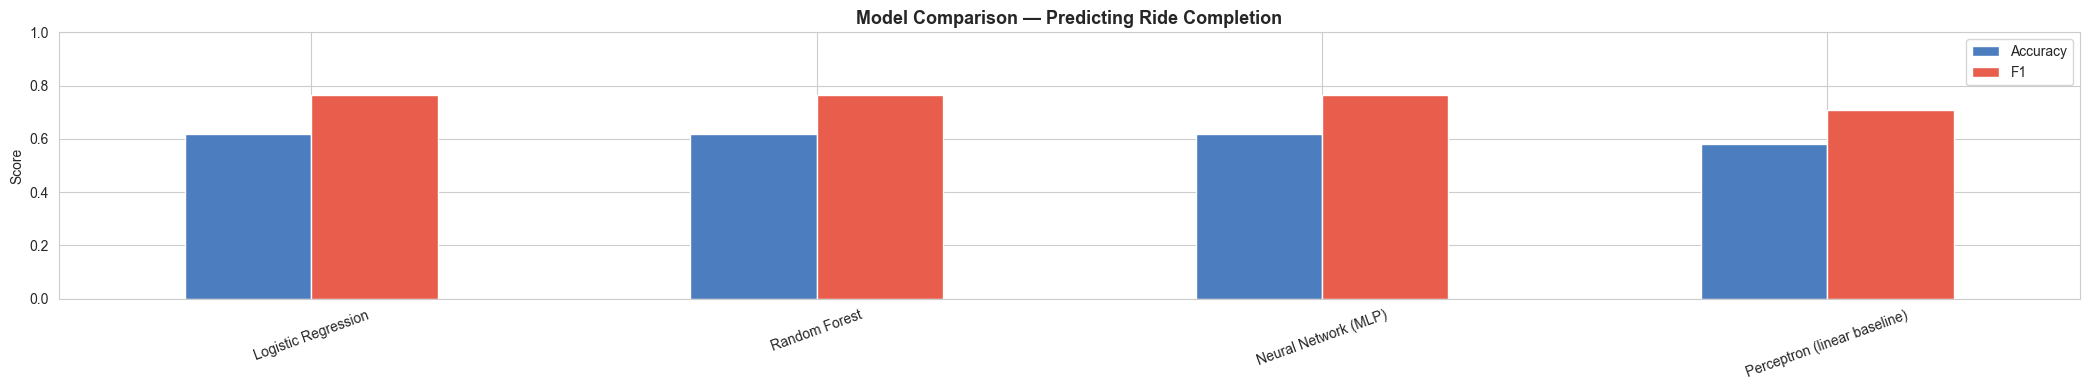


Best performing model: Logistic Regression  (F1 = 0.765)


In [22]:
results['Perceptron (linear baseline)'] = {
    'Accuracy': accuracy_score(yp_test, yp_pred),
    'Precision': precision_score(yp_test, yp_pred),
    'Recall': recall_score(yp_test, yp_pred),
    'F1': f1_score(yp_test, yp_pred)
}

results_df = pd.DataFrame(results).T.round(3).sort_values('F1', ascending=False)
display(results_df)

results_df[['Accuracy', 'F1']].plot(kind='bar', figsize=(21, 4), color=[COLORS[1], COLORS[4]])
plt.title('Model Comparison — Predicting Ride Completion')
plt.ylabel('Score'); plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"\nBest performing model: {results_df.index[0]}  (F1 = {results_df.iloc[0]['F1']:.3f})")


## 14. Business Insights & Recommendations

In [23]:
best_area_name = best_areas.index[0]
best_area_rate = best_areas.iloc[0]['Completion_Rate']

best_route = route_stats_min.sort_values('Total_Bookings', ascending=False).index[0]
best_route_row = route_stats_min.loc[best_route]

best_vehicle = vt_stats['Completion_Rate'].idxmax()
best_vehicle_rev = vt_stats['Revenue_per_km'].idxmax()

best_payment = pay_counts.idxmax()

print('='*70)
print('KEY BUSINESS INSIGHTS')
print('='*70)
print(f'''
1. TOWN / AREA
   -> Best-performing pickup area (min. 200 bookings): "{best_area_name}"
      with a {best_area_rate:.1f}% completion rate.
   -> Highest-demand area: "{top15_volume.index[0]}" ({int(top15_volume.iloc[0]["Total_Bookings"]):,} bookings).

2. ROUTE ("ROAD"/CORRIDOR)
   -> Busiest route: {best_route}
      ({int(best_route_row["Total_Bookings"])} trips, avg fare Rs.{best_route_row["Avg_Booking_Value"]:.0f}).
   -> Most valuable routes (revenue/km) are dominated by longer,
      premium-vehicle corridors — see Section 4 table.

3. VEHICLE TYPE
   -> Most reliable vehicle type: {best_vehicle}
      ({vt_stats.loc[best_vehicle, "Completion_Rate"]:.1f}% completion rate).
   -> Best revenue-per-km vehicle type: {best_vehicle_rev}
      (Rs.{vt_stats.loc[best_vehicle_rev, "Revenue_per_km"]:.2f}/km).

4. PAYMENT
   -> Most-used payment method: {best_payment} ({pay_counts.max():,} transactions).

5. DEMAND PATTERNS
   -> Peak demand hour: {int(hourly.idxmax())}:00 ({int(hourly.max()):,} bookings).
   -> Peak demand day: {dow.idxmax()}.

6. MACHINE LEARNING
   -> Booking value is reasonably well explained by ride distance and
      pickup/turnaround time (Linear Regression R^2 = {r2:.2f}).
   -> {results_df.index[0]} was the strongest model for predicting whether
      a ride would be completed (F1 = {results_df.iloc[0]["F1"]:.2f}), suggesting
      completion risk is only weakly explained by vehicle type/time-of-day alone
      -> operational factors (driver supply, distance to pickup) likely matter more.
   -> K-Means uncovered {K_FINAL} distinct ride personas (short/cheap vs long/premium).
   -> DBSCAN flagged a small subset of rides as statistical outliers, useful
      for fraud/anomaly review.
''')


KEY BUSINESS INSIGHTS

1. TOWN / AREA
   -> Best-performing pickup area (min. 200 bookings): "Welcome"
      with a 66.0% completion rate.
   -> Highest-demand area: "Khandsa" (949 bookings).

2. ROUTE ("ROAD"/CORRIDOR)
   -> Busiest route: DLF City Court -> Bhiwadi
      (17 trips, avg fare Rs.429).
   -> Most valuable routes (revenue/km) are dominated by longer,
      premium-vehicle corridors — see Section 4 table.

3. VEHICLE TYPE
   -> Most reliable vehicle type: Uber XL
      (63.0% completion rate).
   -> Best revenue-per-km vehicle type: Go Sedan
      (Rs.20.78/km).

4. PAYMENT
   -> Most-used payment method: UPI (45,909 transactions).

5. DEMAND PATTERNS
   -> Peak demand hour: 18:00 (12,397 bookings).
   -> Peak demand day: Monday.

6. MACHINE LEARNING
   -> Booking value is reasonably well explained by ride distance and
      pickup/turnaround time (Linear Regression R^2 = -0.00).
   -> Logistic Regression was the strongest model for predicting whether
      a ride would be

### Recommendations
1. **Reallocate driver supply** toward the lowest-completion-rate pickup areas identified in Section 3 — these represent the biggest opportunity to recover lost bookings.
2. **Promote the top revenue-per-km vehicle type** more heavily on high-value corridors identified in Section 4.
3. **Target driver incentives around peak hours/days** (Section 2) to reduce "No Driver Found" cancellations.
4. **Use the completion-prediction model** (Section 9/12) in production to proactively flag high-risk bookings and pre-emptively offer a backup vehicle type.
5. **Monitor DBSCAN-flagged outlier trips** (Section 11) for potential fraud, data errors, or premium-service opportunities.

---
*End of analysis.*
